# 🧠 Deep Learning PR 3

## Computer Vision Pipeline using OpenCV, YuNet & YOLOv8


##  Project Overview

This project focuses on building a computer vision pipeline using classical image processing and deep learning techniques. The pipeline covers morphological operations, bitwise operations, image histograms, face detection using YuNet, and object detection using YOLOv8.


##  Project Objectives

- Perform morphological operations for image preprocessing.
- Apply bitwise operations using image masks.
- Analyze grayscale and color image histograms.
- Detect faces using the YuNet face detection model.
- Detect objects using the YOLOv8 object detection model.
- Integrate face and object detection into a real-time webcam pipeline.
- Compare the performance and FPS of different techniques.


##  Technologies Used

- Python
- OpenCV 5.0.0
- NumPy
- Matplotlib
- Ultralytics YOLOv8
- YuNet Face Detection
- Jupyter Notebook

---

## 📁 Dataset & Model Sources

### Images
- OpenCV sample images
- 2–3 personal/phone photographs for testing

### Models
- **YuNet:** `face_detection_yunet_2023mar.onnx`
- **YOLOv8:** `yolov8n.pt`

The images will be stored in `/data/images` and model files in `/data/models`.

---

# Task 1: Environment Setup, Image I/O & Morphological Operations

### Objective

Set up the computer vision environment, perform basic image processing, and apply morphological operations using OpenCV.

### Expected Output

Loaded images, binary thresholding results, morphology operation comparisons, and kernel-shape comparisons displayed using Matplotlib.


### 1.1 Environment Setup & Image Loading

In this step, we import the required libraries, check the OpenCV version, load a grayscale and a color image, and display their shape and data type.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV Version:", cv2.__version__)

gray_image = cv2.imread("data/images/morphology.jpg", cv2.IMREAD_GRAYSCALE)
color_image = cv2.imread("data/images/morphology.jpg", cv2.IMREAD_COLOR)

print("Grayscale Shape:", gray_image.shape)
print("Grayscale Data Type:", gray_image.dtype)

print("Color Shape:", color_image.shape)
print("Color Data Type:", color_image.dtype)

# Helper function to display images
def show(img, title="Image"):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

OpenCV Version: 5.0.0
Grayscale Shape: (314, 327)
Grayscale Data Type: uint8
Color Shape: (314, 327, 3)
Color Data Type: uint8


### 1.2 Binarize a Test Image

Convert the test image to grayscale and apply binary thresholding at 127 to create the input for morphological experiments.

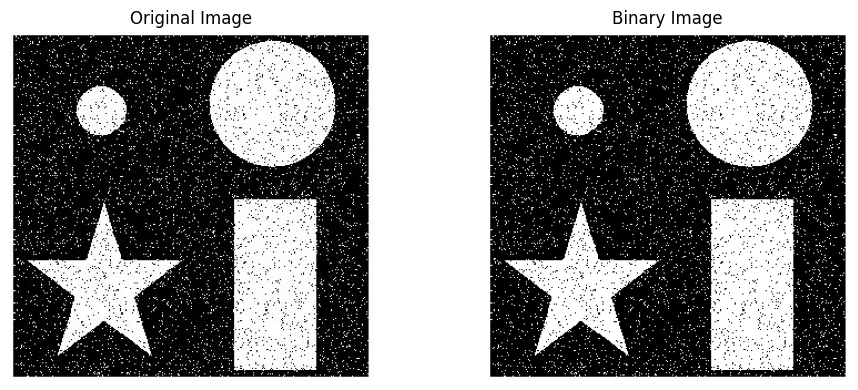

In [5]:
gray = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Display original and binary images
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.tight_layout()
plt.savefig("plots/binary_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The image was successfully converted into a binary image using a threshold value of 127. The binary image separates the foreground shapes from the background and can be used as input for morphological operations.

### 1.3 Apply the Four Morphological Operations

Apply erosion, dilation, opening, and closing using a 5×5 rectangular kernel to observe their effects on the binary image.

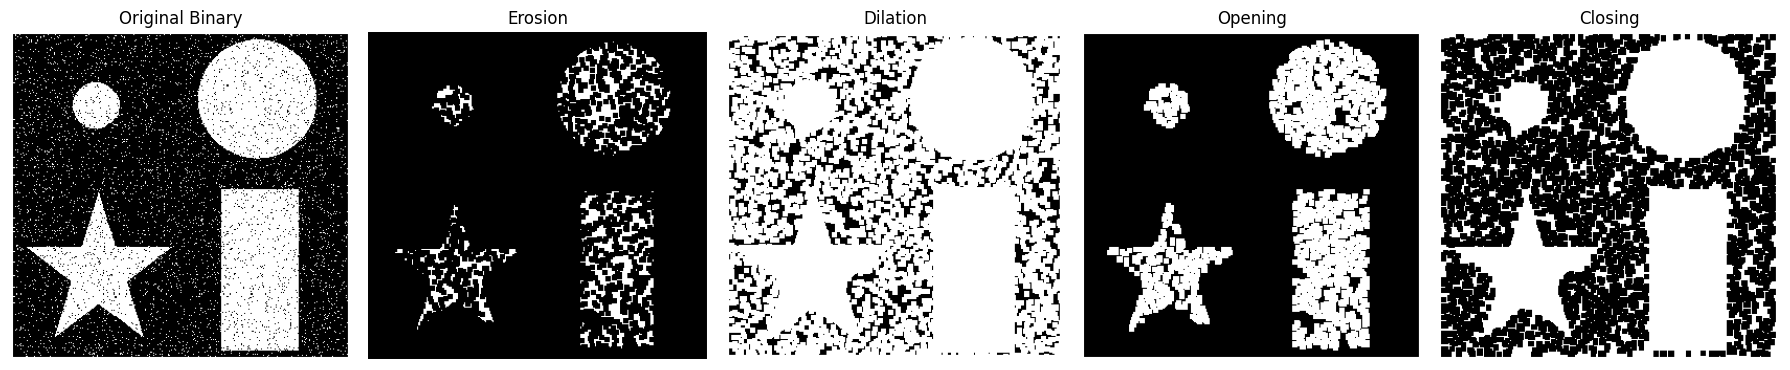

In [6]:
kernel = np.ones((5, 5), np.uint8)

eroded = cv2.erode(binary, kernel)
dilated = cv2.dilate(binary, kernel)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(18, 4))

images = [binary, eroded, dilated, opened, closed]
titles = ["Original Binary", "Erosion", "Dilation", "Opening", "Closing"]

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.savefig("plots/morphology_operations.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Erosion reduces foreground regions, while dilation expands them. Opening helps remove small noise, whereas closing fills small gaps and holes in the foreground objects.

### 1.4 Kernel Shape & Size Comparison

Compare opening and closing using rectangular, elliptical, and cross-shaped kernels at different sizes to determine which combination removes salt-and-pepper noise while preserving object outlines.

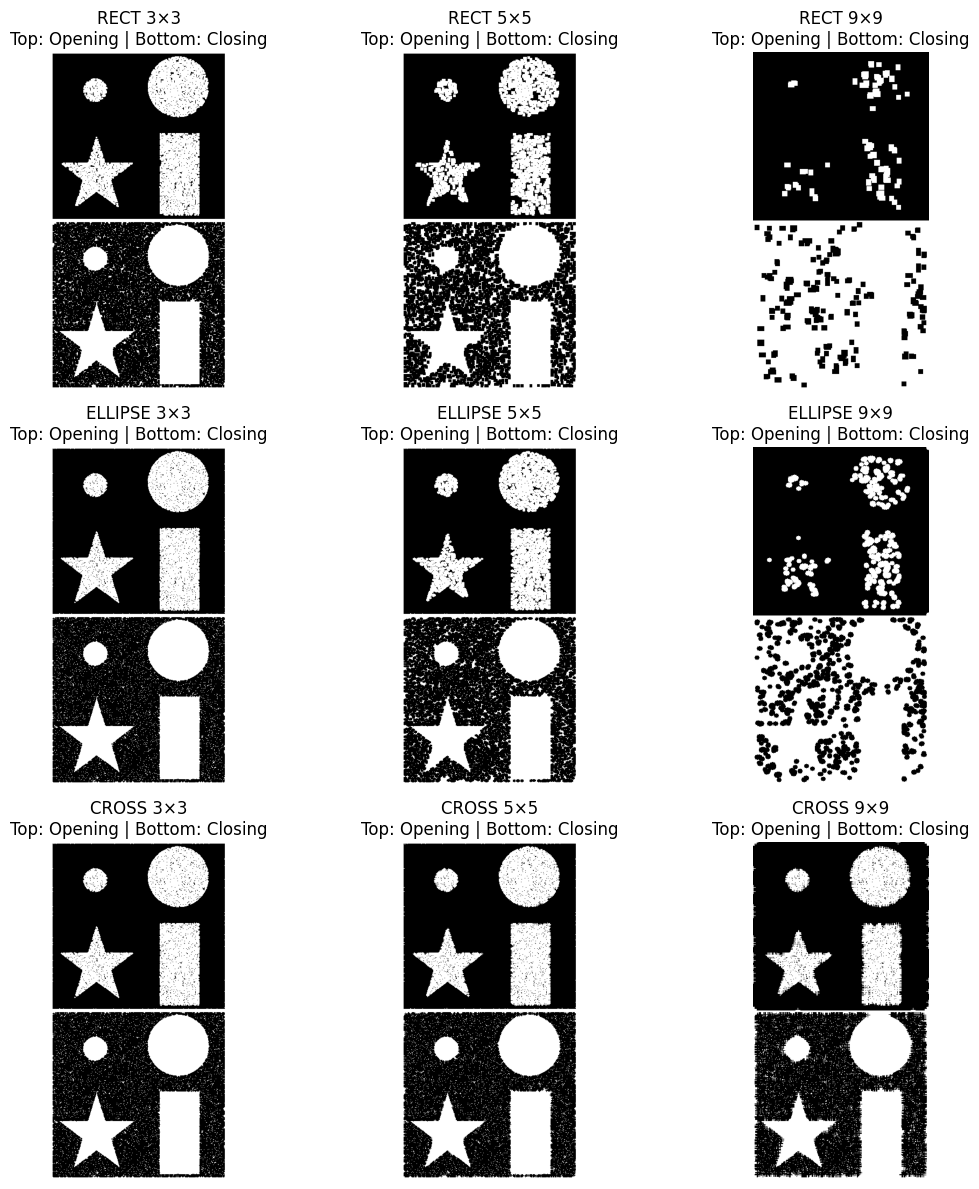

In [ ]:
kernel_shapes = {"RECT": cv2.MORPH_RECT,
                 "ELLIPSE": cv2.MORPH_ELLIPSE,
                 "CROSS": cv2.MORPH_CROSS}

kernel_sizes = [3, 5, 9]

plt.figure(figsize=(12, 12))

plot_index = 1

for shape_name, shape_type in kernel_shapes.items():
    for size in kernel_sizes:

        kernel = cv2.getStructuringElement(shape_type, (size, size))

        opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
        closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

        combined = np.vstack((opening, closing))

        plt.subplot(3, 3, plot_index)
        plt.imshow(combined, cmap="gray")
        plt.title(f"{shape_name} {size}×{size}\nTop: Opening | Bottom: Closing")
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.savefig("plots/morphology_grid.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The CROSS 5×5 kernel gives the best balance for this image. It removes a good amount of salt-and-pepper noise while preserving the main object outlines better than the larger 9×9 kernels.

### 1.5 Why Morphology Works

- **Erosion:** Works like a local minimum filter. It shrinks white regions and removes small bright noise.
- **Dilation:** Works like a local maximum filter. It grows white regions and fills small dark gaps.
- **Opening:** Erosion → Dilation. It removes small noise while preserving the overall shape.
- **Closing:** Dilation → Erosion. It fills small holes and gaps without significantly shrinking the object.

### Real-World Scenarios

- **Erosion:** Remove small unwanted bright spots before object detection.
- **Dilation:** Connect broken parts of an object or fill small gaps in a detected region.
- **Opening:** Remove salt-and-pepper noise from a camera image before passing the mask to a detector.
- **Closing:** Fill small holes or breaks in an object mask before passing it to a downstream detector.

---

# Task 2: Bitwise Operations & Image Histograms

### Objective

Apply bitwise operations using binary masks and analyze grayscale and colour image histograms for image processing.

### Expected Output

Bitwise mask results, masked image overlays, grayscale and colour histograms, and brightness/contrast comparisons displayed using Matplotlib.



### 2.1 Bitwise AND / OR / XOR / NOT

Create two binary masks using a circle and rectangle, then apply AND, OR, XOR, and NOT operations to observe how binary masks can be combined and modified.

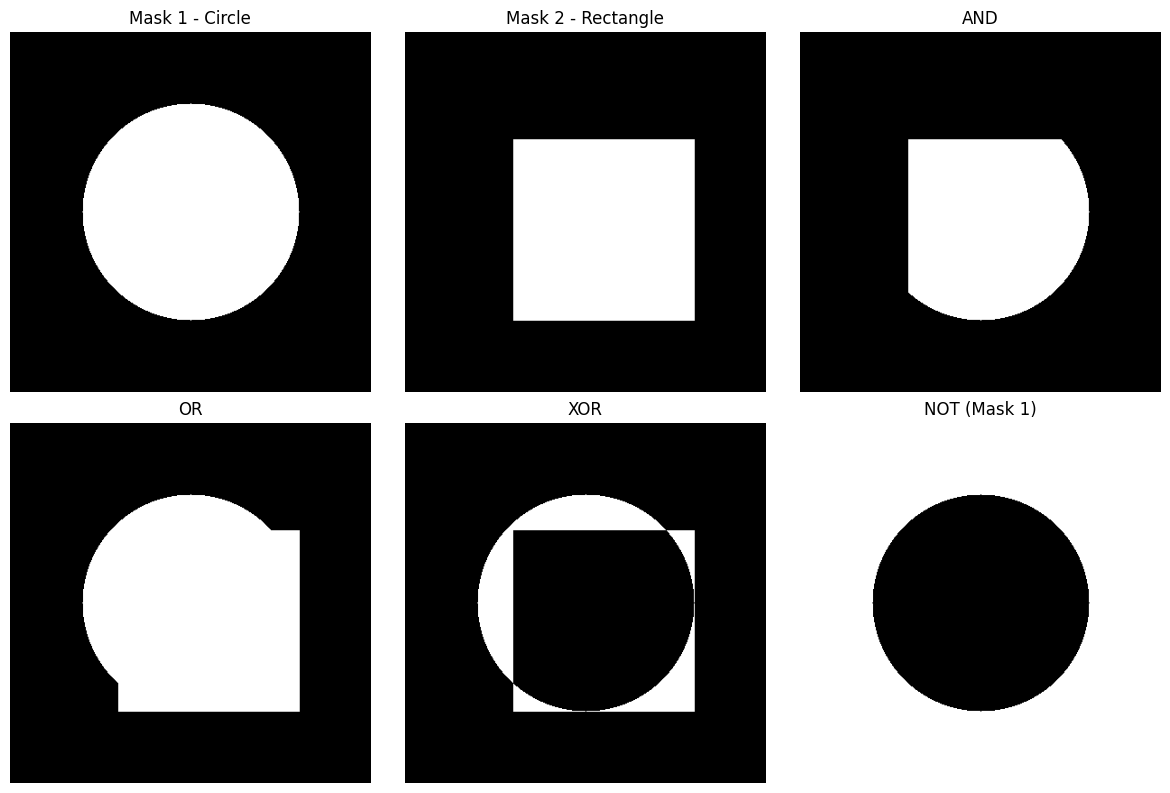

In [ ]:
mask1 = np.zeros((400, 400), dtype=np.uint8)
mask2 = np.zeros((400, 400), dtype=np.uint8)

cv2.circle(mask1, (200, 200), 120, 255, -1)
cv2.rectangle(mask2, (120, 120), (320, 320), 255, -1)

bitwise_and = cv2.bitwise_and(mask1, mask2)
bitwise_or = cv2.bitwise_or(mask1, mask2)
bitwise_xor = cv2.bitwise_xor(mask1, mask2)
bitwise_not = cv2.bitwise_not(mask1)

plt.figure(figsize=(12, 8))

images = [mask1, mask2, bitwise_and, bitwise_or, bitwise_xor, bitwise_not]

titles = ["Mask 1 - Circle", "Mask 2 - Rectangle", "AND", "OR", "XOR", "NOT (Mask 1)"]

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.savefig("plots/bitwise_operations.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

- **AND:** Keeps only the overlapping region of the two masks.
- **OR:** Combines the regions covered by either mask.
- **XOR:** Keeps regions that belong to only one mask.
- **NOT:** Inverts the mask, changing white areas to black and vice versa.

### 2.2 Applied Use-Case: Masked Overlay

Use a circular mask to extract a region from a real photograph and apply a simple watermark using a bitwise OR operation.

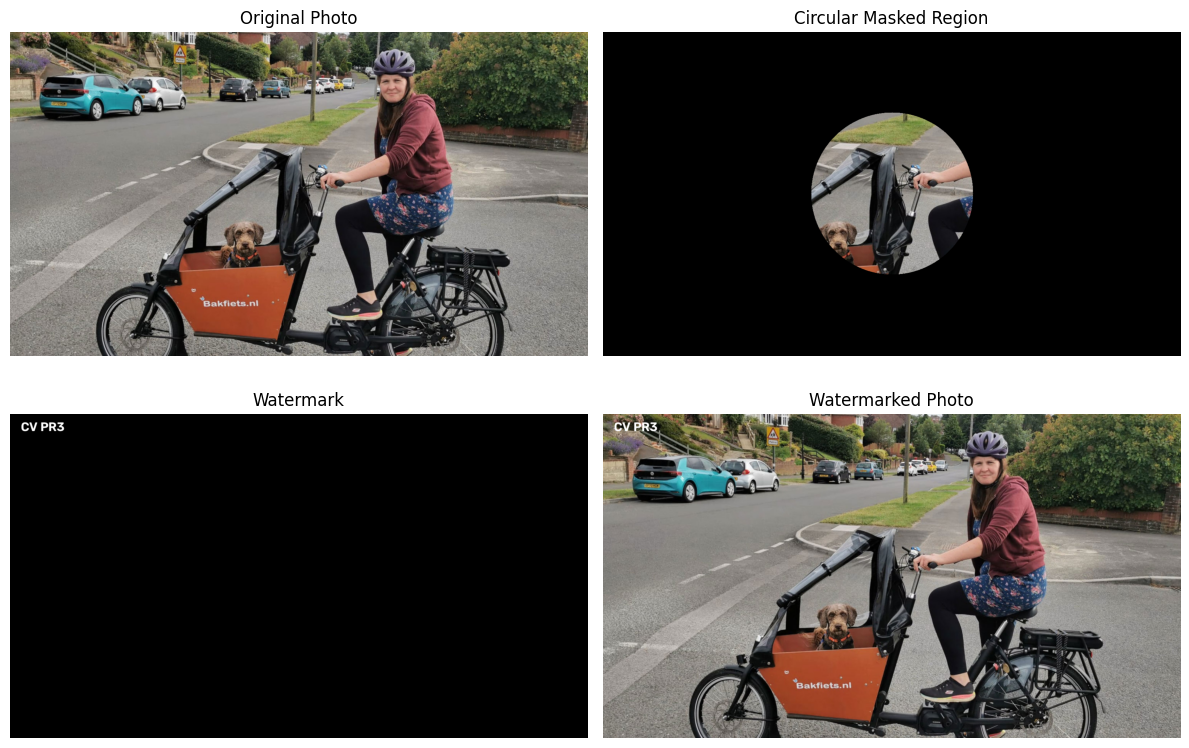

In [ ]:
photo = cv2.imread("data/images/objects.jpg")

# Create a circular mask
mask = np.zeros(photo.shape[:2], dtype=np.uint8)
center = (photo.shape[1] // 2, photo.shape[0] // 2)
radius = min(photo.shape[0], photo.shape[1]) // 4

cv2.circle(mask, center, radius, 255, -1)

masked_region = cv2.bitwise_and(photo, photo, mask=mask)

# Create a simple watermark
watermark = np.zeros_like(photo)
cv2.putText(watermark, "CV PR3", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)

watermarked = cv2.bitwise_or(photo, watermark)

plt.figure(figsize=(12, 8))

images = [photo, masked_region, watermark, watermarked]
titles = ["Original Photo", "Circular Masked Region", "Watermark", "Watermarked Photo"]

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.savefig("plots/masked_overlay.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

- The circular mask extracts only the selected region from the photograph using `bitwise_and()`.
- The watermark is combined with the background image using `bitwise_or()`.
- These operations are useful for region-of-interest processing and adding simple image overlays.

### 2.3 Grayscale & Per-Channel Colour Histograms

Compute and visualize the grayscale histogram and the individual B, G, and R colour-channel histograms to analyze the distribution of pixel intensities.

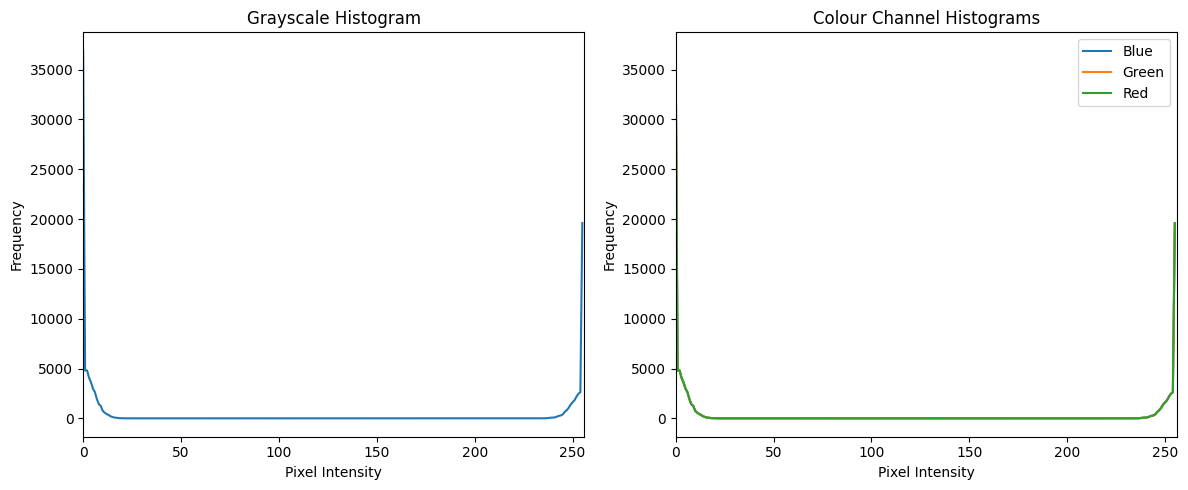

In [ ]:
# Calculate grayscale histogram
gray_hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

blue_hist = cv2.calcHist([color_image], [0], None, [256], [0, 256])
green_hist = cv2.calcHist([color_image], [1], None, [256], [0, 256])
red_hist = cv2.calcHist([color_image], [2], None, [256], [0, 256])

plt.figure(figsize=(12, 5))

# Grayscale histogram
plt.subplot(1, 2, 1)
plt.plot(gray_hist)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

# Colour channel histograms
plt.subplot(1, 2, 2)
plt.plot(blue_hist, label="Blue")
plt.plot(green_hist, label="Green")
plt.plot(red_hist, label="Red")
plt.title("Colour Channel Histograms")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()

plt.tight_layout()
plt.savefig("plots/histogram_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

- The grayscale histogram shows how pixel intensities are distributed from dark to bright values.
- The colour histograms show the intensity distribution of the Blue, Green, and Red channels.
- Peaks indicate intensity ranges that occur more frequently in the image.

### 2.4 Brightness & Contrast Adjustment

Adjust the brightness and contrast of the image using different alpha and beta values, then compare the resulting images and their grayscale histograms.

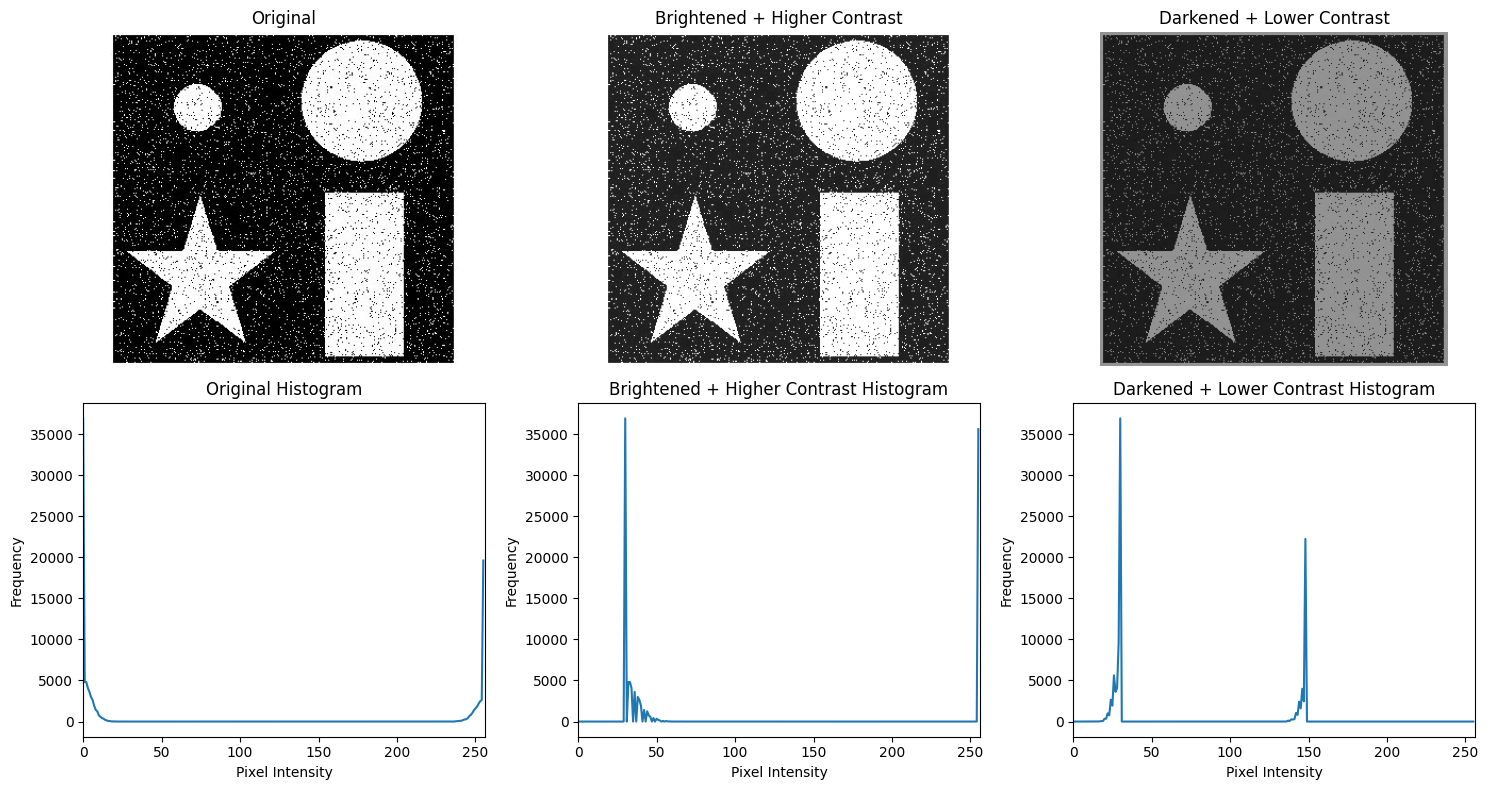

In [ ]:
# Adjust brightness and contrast
brightened = cv2.convertScaleAbs(color_image, alpha=1.5, beta=30)
darkened = cv2.convertScaleAbs(color_image, alpha=0.7, beta=-30)

# Convert all images to grayscale
original_gray = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)
bright_gray = cv2.cvtColor(brightened, cv2.COLOR_BGR2GRAY)
dark_gray = cv2.cvtColor(darkened, cv2.COLOR_BGR2GRAY)

# Calculate grayscale histograms
hist_original = cv2.calcHist([original_gray], [0], None, [256], [0, 256])
hist_bright = cv2.calcHist([bright_gray], [0], None, [256], [0, 256])
hist_dark = cv2.calcHist([dark_gray], [0], None, [256], [0, 256])

plt.figure(figsize=(15, 8))

images = [color_image, brightened, darkened]
image_titles = ["Original", "Brightened + Higher Contrast", "Darkened + Lower Contrast"]
histograms = [hist_original, hist_bright, hist_dark]

for i in range(3):
    # Image
    plt.subplot(2, 3, i + 1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(image_titles[i])
    plt.axis("off")

    # Histogram
    plt.subplot(2, 3, i + 4)
    plt.plot(histograms[i])
    plt.title(f"{image_titles[i]} Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.xlim([0, 256])

plt.tight_layout()
plt.savefig("plots/brightness_contrast.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

- The brightened image has more pixels shifted toward higher intensity values.
- The darkened image has more pixels concentrated toward lower intensity values.
- Increasing contrast spreads the intensity distribution, while decreasing contrast makes the distribution narrower.

### 2.5 Why Alpha/Beta and Histograms Matter

The new pixel value is calculated as:

**new_pixel = alpha × pixel + beta**

- **Alpha (contrast gain):** Stretches or compresses the histogram spread around its mean.
- **Beta (brightness offset):** Shifts the histogram left or right.
- A **narrow histogram** indicates low contrast or a washed-out image.
- A histogram clipped at **0 or 255** can indicate under-exposure or over-exposure.
- This diagnostic view helps determine whether an image needs pre-processing before being passed to the face or object detectors in later tasks.

---

# Task 3: Face Detection with YuNet (OpenCV 5.0)

### Objective

Use the YuNet face detector to detect and visualize faces under different poses, lighting conditions, and levels of occlusion.

### Expected Output

YuNet detections on static images and webcam frames, including face bounding boxes, facial landmarks, confidence scores, threshold comparison, and an applied face-blurring example.



### 3.1 Load the YuNet Face Detector

Load the YuNet face detection model and configure it according to the dimensions of the input image.

In [ ]:
img = cv2.imread("data/images/people1.jpg")

img_h, img_w = img.shape[:2]
detector = cv2.FaceDetectorYN_create("data/models/face_detection_yunet_2023mar.onnx", "", (img_w, img_h), score_threshold=0.9)

detector.setInputSize((img_w, img_h))

_, faces = detector.detect(img)

print("Number of faces detected:", 0 if faces is None else len(faces))

Number of faces detected: 1


### 3.2 Detect Faces on Static Images

Run YuNet on four static images with different poses, lighting, and numbers of people, and visualize face boxes, five facial landmarks, and confidence scores.

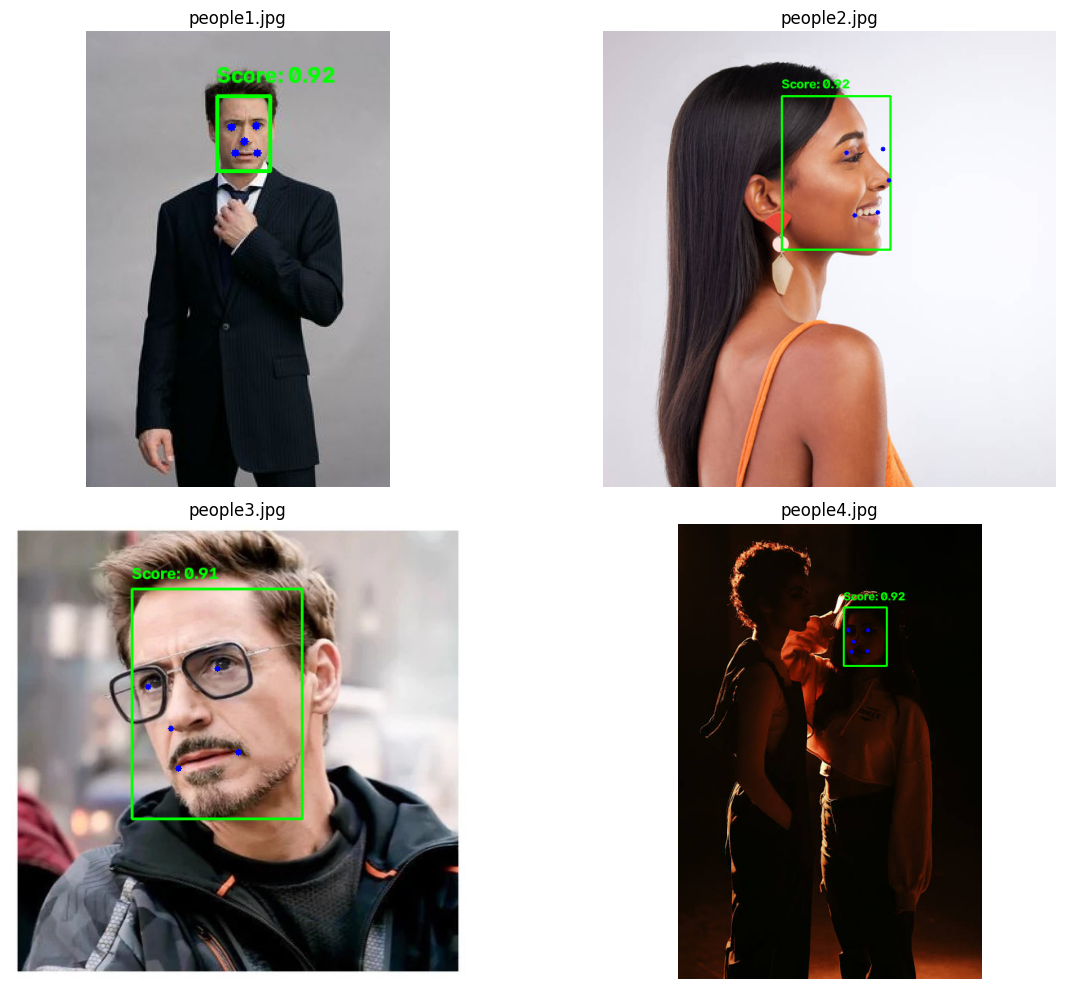

In [ ]:
image_paths = ["data/images/people1.jpg",
               "data/images/people2.jpg",
               "data/images/people3.jpg",
               "data/images/people4.jpg"]

plt.figure(figsize=(14, 10))

for i, path in enumerate(image_paths):
    img = cv2.imread(path)

    img_h, img_w = img.shape[:2]

    detector.setInputSize((img_w, img_h))

    _, faces = detector.detect(img)

    result = img.copy()

    if faces is not None:
        for face in faces:
            # Face bounding box
            x, y, w, h = face[:4].astype(int)

            cv2.rectangle(result, (x, y), (x + w, y + h), (0, 255, 0), 2)

            landmarks = face[4:14].reshape(5, 2).astype(int)

            for point in landmarks:
                cv2.circle(result, tuple(point), 3, (255, 0, 0), -1)

            # Confidence score
            score = face[14]
            cv2.putText(result, f"Score: {score:.2f}", (x, max(y - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    plt.subplot(2, 2, i + 1)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title(path.split("/")[-1])
    plt.axis("off")

plt.tight_layout()
plt.savefig("plots/face_detection_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

- YuNet successfully detected faces across different poses and lighting conditions with confidence scores around 0.91–0.92.
- The side-profile and sunglasses images were detected successfully.
- In the dark-lighting image, YuNet detected one face but missed the other, showing that challenging lighting can affect detection performance.

### 3.3 Real-Time Detection on Webcam

Run YuNet on live webcam frames, displaying face boxes, landmarks, confidence scores, and the achieved FPS.

In [ ]:
import cv2
import time

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
else:
    prev_time = time.time()
    input_size = None
    fps = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            print("Error: Could not read webcam frame.")
            break

        h, w = frame.shape[:2]

        if input_size != (w, h):
            detector.setInputSize((w, h))
            input_size = (w, h)

        _, faces = detector.detect(frame)

        # Draw detections
        if faces is not None:
            for face in faces:
                x, y, fw, fh = face[:4].astype(int)

                cv2.rectangle(frame, (x, y), (x + fw, y + fh), (0, 255, 0), 2)

                # Draw 5 landmarks
                landmarks = face[4:14].reshape(5, 2).astype(int)

                for point in landmarks:
                    cv2.circle(frame, tuple(point), 3, (255, 0, 0), -1)

                # Confidence score
                score = face[14]
                cv2.putText(frame, f"Score: {score:.2f}", (x, max(y - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        current_time = time.time()
        fps = 1 / (current_time - prev_time)
        prev_time = current_time

        cv2.putText(frame, f"FPS: {fps:.2f}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255),2)

        cv2.imshow("YuNet Real-Time Face Detection", frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()

    print(f"Achieved FPS: {fps:.2f}")

KeyboardInterrupt: 

: 